# 1 — Quickstart: fitting your first neural copula

This notebook covers the whole loop in about thirty lines: generate data with a known
dependence structure, fit a `NeuroCopula` to it, check the fit did not overfit, and ask
it the probabilistic questions a copula exists to answer.

**What a copula is, in one line.** Any joint distribution factorises into its *marginals*
(what each variable does on its own) and its *copula* (how they move together):

$$p(x_1, \dots, x_d) = c\big(F_1(x_1), \dots, F_d(x_d)\big) \cdot \prod_j f_j(x_j)$$

Classical copula models pick a parametric family for $c$ — Gaussian, Student-t, Clayton —
and inherit whatever tail behaviour that family imposes. `neurocopula` learns $c$ with a
normalizing flow instead, so its shape is inferred rather than assumed, while the
marginals $F_j$ are reproduced exactly by their empirical distribution functions.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from neurocopula import NeuroCopula, datasets, plotting as ncplot, theme

pd.set_option("display.width", 120, "display.precision", 4)

# Apply the library's visual theme, so hand-rolled figures in this notebook
# match the ones the library produces. rcParams are read when an Axes is
# created, so this must run before any plotting.
theme.apply_theme()

## The data

`datasets.make_clayton` draws from a **Clayton copula** with Student-t marginals. Clayton
is the canonical "crashes together, rallies independently" shape: strong dependence in the
lower tail, none in the upper. Because it is a standard family we know its true tail
dependence in closed form, which gives us something to check the fit against.

In [2]:
df = datasets.make_clayton(n=4000, theta=2.0, marginals="t", df=4, seed=0)
truth = datasets.theoretical_tail_dependence("clayton", theta=2.0)

print(df.describe().round(3))
print()
print(f"true lower tail dependence : {truth['lower']:.4f}")
print(f"true upper tail dependence : {truth['upper']:.4f}")
print(f"true Kendall's tau         : {datasets.theoretical_kendall_tau('clayton', theta=2.0):.4f}")

             x1        x2
count  4000.000  4000.000
mean     -0.019     0.001
std       1.422     1.529
min     -11.060   -12.646
25%      -0.751    -0.738
50%      -0.022    -0.002
75%       0.741     0.750
max       8.934    31.610

true lower tail dependence : 0.7071
true upper tail dependence : 0.0000
true Kendall's tau         : 0.5000


## Fit

The defaults are chosen for the small-to-medium tabular data this library targets:

- `copula_mode=True` — the flow sees Gaussianized ranks, so it only ever learns dependence.
- `split_method="chronological"` — validation is the most recent slice of rows. That is the
  right default for time series, since it tests whether the fit generalises *forward*.
  Our rows here are i.i.d., so we pass `"random"` instead.

`fit` does two passes: one on a train/validation split to find the epoch count where
validation stops improving, then a refit on **100%** of the rows at that epoch count — so
the split diagnoses overfitting without permanently costing you data.

In [3]:
model = NeuroCopula(
    transforms=4,
    hidden_features=(64, 64),
    copula_mode=True,
    seed=0,
).fit(df, epochs=800, patience=60, split_method="random", verbose=True)

split=random (train n=3200, val n=800)  copula_mode=True  bayesian=False  sampling_mode=autoregressive  device=cpu


[val split] epoch    0  train_nll=   3.749  val_nll=   3.268


[val split] epoch   80  train_nll=   2.394  val_nll=   2.390


[val split] early stop at epoch 123 (best epoch 63)

--- fit summary (from the train/val split) ---
  n_train: 3200
  n_val: 800
  n_features: 2
  best_epoch: 63
  final_train_nll: 2.396500825881958
  final_val_nll: 2.388575553894043
  overfit_gap: -0.007925271987915039
  n_parameters: 29368
  refit_on_full_data: True
  overfitting check (val - train = -0.008): looks OK

refitting on 100% of the data for 64 epochs...


done. final full-data train NLL: 2.394


The `overfit_gap` above is validation NLL minus training NLL. Below ~0.5 the fit is
healthy; a large gap means the flow is memorising, and the answer is more data, fewer
`transforms`, narrower `hidden_features`, or some `weight_decay`.

## Diagnostics

One figure, four questions: did it train cleanly, did it get the rank dependence right,
what does the dependence look like with marginals stripped out, and are the marginals
intact?

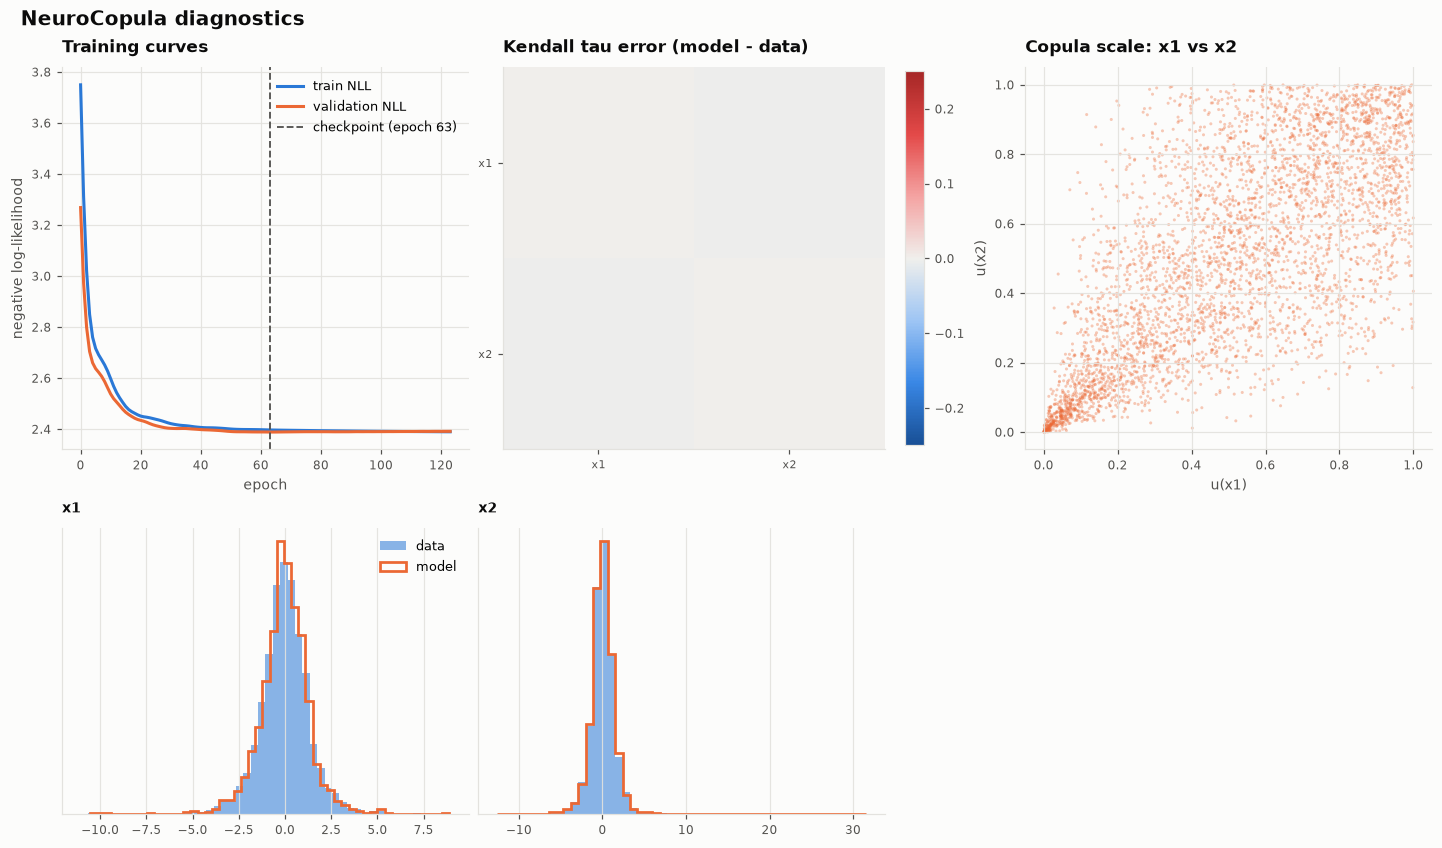

In [4]:
fig = ncplot.plot_diagnostics(model, data=df, n_samples=5000)
plt.show()

The training curves show the checkpoint the deployed model was taken at. The Kendall tau
error panel is near-white, meaning the model reproduces the rank dependence. The
copula-scale scatter shows the giveaway Clayton shape: points crowding into the
bottom-left corner and fanning out towards the top-right.

## Question 1 — how likely are both to crash at once?

This is the question a copula is *for*. Marginal models can each tell you that a 2-sigma
drop happens sometimes; only the joint tells you how often they happen **together**.

In [5]:
scenarios = {
    "both below -1": {"x1": ("<", -1.0), "x2": ("<", -1.0)},
    "both below -2": {"x1": ("<", -2.0), "x2": ("<", -2.0)},
    "both below -3": {"x1": ("<", -3.0), "x2": ("<", -3.0)},
}

rows = []
for label, conditions in scenarios.items():
    joint = model.joint_exceedance_probability(conditions, n_mc=200_000)
    # If the two moved independently, the joint probability would just be the
    # product of the two marginal probabilities. The ratio is the dependence.
    marginals = [model.joint_exceedance_probability({c: v}, n_mc=200_000)
                 for c, v in conditions.items()]
    independent = float(np.prod(marginals))
    rows.append({
        "scenario": label,
        "P(joint)": joint,
        "P if independent": independent,
        "times more likely": joint / independent if independent > 0 else np.nan,
    })

pd.DataFrame(rows).set_index("scenario").round(5)

,P(joint),P if independent,times more likely
scenario,,,
both below -1,0.1331,0.0347,3.8357
both below -2,0.0437,0.0036,12.1044
both below -3,0.0171,0.0006,31.2569


Read the last column. The further into the tail you go, the more the dependence matters:
treating these two as independent understates the risk of a joint crash by a growing
multiple. That multiple is the entire practical case for fitting a copula.

## Question 2 — tail dependence

The tail dependence coefficient formalises it:

$$\lambda_L(q) = P\big(U_2 < q \mid U_1 < q\big)$$

"given one has fallen into its worst $q$ of outcomes, how likely is the other to be there
too". We check the model against the truth we know.

In [6]:
lam_l = model.tail_dependence("x1", "x2", q=0.02, tail="lower", n_mc=200_000)
lam_u = model.tail_dependence("x1", "x2", q=0.02, tail="upper", n_mc=200_000)

print(f"lower : model {lam_l:.3f}   theory {truth['lower']:.3f}   error {abs(lam_l-truth['lower']):.3f}")
print(f"upper : model {lam_u:.3f}   theory {truth['upper']:.3f}   error {abs(lam_u-truth['upper']):.3f}")
print()
print("The model learned the ASYMMETRY: strong dependence going down, almost none going up.")
print("No elliptical copula (Gaussian, Student-t) can represent that -- they force the two to be equal.")

lower : model 0.728   theory 0.707   error 0.021
upper : model 0.065   theory 0.000   error 0.065

The model learned the ASYMMETRY: strong dependence going down, almost none going up.
No elliptical copula (Gaussian, Student-t) can represent that -- they force the two to be equal.


## Question 3 — conditional probabilities

The same dependence, restated in units a decision-maker can act on: *given `x1` has
crashed, how likely is `x2` to crash?*

In [7]:
crash, ess_crash = model.conditional_probability("x2", "<", -2.0, given={"x1": -3.0}, tol=0.3)
calm,  ess_calm  = model.conditional_probability("x2", "<", -2.0, given={"x1":  0.0}, tol=0.3)

print(f"P(x2 < -2 | x1 = -3.0)  = {crash:.3f}   (effective n = {ess_crash:.0f})")
print(f"P(x2 < -2 | x1 =  0.0)  = {calm:.3f}   (effective n = {ess_calm:.0f})")
print(f"\nratio: {crash / calm:.0f}x more likely when x1 has already crashed")

P(x2 < -2 | x1 = -3.0)  = 0.661   (effective n = 3978)
P(x2 < -2 | x1 =  0.0)  = 0.003   (effective n = 23811)

ratio: 250x more likely when x1 has already crashed


Always check the **effective sample size**. Conditioning is done by importance-weighting a
large Monte Carlo sample, so if the conditioning point sits in a sparse region only a few
draws carry any weight and the answer is noise. The library warns below 100; widen `tol`
or raise `n_mc` when that happens.

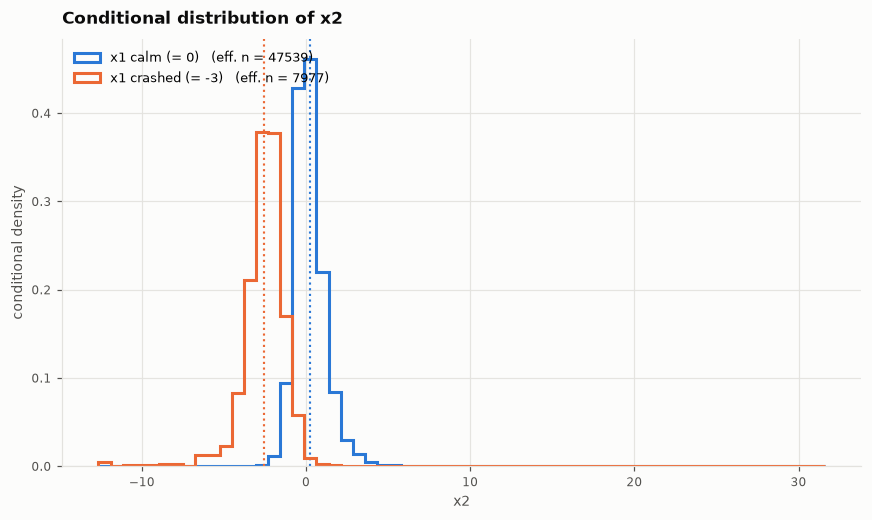

In [8]:
fig = ncplot.plot_conditional_distribution(
    model, target="x2",
    given_list=[{"x1": 0.0}, {"x1": -3.0}],
    labels=["x1 calm (= 0)", "x1 crashed (= -3)"],
    tol=0.3, n_mc=120_000,
)
plt.show()

Conditioning on a crash does not merely shift the distribution left — it changes its
shape, piling mass into the lower tail. That is dependence structure a correlation
coefficient cannot express.

## Sampling and persistence

A fitted model is a generator: draw as many synthetic rows as you like, in original units,
with the marginals reproduced exactly.

In [9]:
synthetic = model.sample(5000)
comparison = pd.DataFrame({
    "data": df.describe().loc[["mean", "std", "min", "max"], "x1"],
    "synthetic": synthetic.describe().loc[["mean", "std", "min", "max"], "x1"],
})
print(comparison.round(3))

path = model.save("quickstart_model.pt")
reloaded = NeuroCopula.load(path)
print(f"\nsaved and reloaded; log-densities identical: "
      f"{np.allclose(reloaded.log_prob(df.head()), model.log_prob(df.head()))}")

        data  synthetic
mean  -0.019     -0.045
std    1.422      1.438
min  -11.060    -10.607
max    8.934      8.934

saved and reloaded; log-densities identical: True


In [10]:
import os
os.remove("quickstart_model.pt")   # tidy up

## Where to go next

| Notebook | Question it answers |
|---|---|
| `02_tail_dependence.ipynb` | Why a Gaussian copula is dangerous, and how to see it |
| `03_conditional_queries.ipynb` | Stress testing and conditional risk in depth |
| `04_bayesian_uncertainty.ipynb` | How much should you trust a single estimate? |
| `05_multivariate_panel.ipynb` | Scaling past two dimensions |
| `06_vine_comparison.ipynb` | Head-to-head against vine copulas |
| `../benchmarks/benchmark_suite.ipynb` | The full benchmark, reproduced end to end |